# GDELT × Bénin : Détection d'anomalies temporelles
**Hackathon iSHEERO × DataCamp 2026 : Bénin Insights Challenge**


Ce notebook détecte et analyse les **pics d'événements anormaux** dans les données GDELT  
du Bénin sur l'année 2025, en combinant trois approches complémentaires.

> **Résultat principal :** Le pic du **7-8 décembre 2025** (+1240% vs médiane journalière)  
> correspond à une **tentative de coup d'État** déjouée par les forces loyalistes béninoises.

## Sommaire
1. [Imports et chargement](#1)
2. [Construction de la série temporelle journalière](#2)
3. [Méthode 1 — Z-score global](#3)
4. [Méthode 2 — Z-score sur fenêtre glissante (rolling 14j)](#4)
5. [Méthode 3 — Score composite multi-dimensionnel](#5)
6. [Synthèse des anomalies détectées](#6)
7. [Zoom : le pic du 7-8 décembre 2025](#7)
8. [Interprétation et recommandations](#8)


## 1. Imports et chargement <a id='1'></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#FAFAFA', 'axes.facecolor': '#FAFAFA',
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'font.family': 'DejaVu Sans', 'axes.spines.top': False,
    'axes.spines.right': False, 'figure.dpi': 130,
})

COLORS = {
    'normal':    '#2E86AB',
    'warning':   '#F6AE2D',
    'anomaly':   '#F26419',
    'coup':      '#E8112D',
    'goldstein': '#5BC0BE',
    'tone':      '#8E8E93',
}

INPUT_FILE = "../data/GDELT_events_benin_2025_cleaned.csv"

df = pd.read_csv(INPUT_FILE, low_memory=False)
df['date'] = pd.to_datetime(df['SQLDATE'].astype(str), format='ISO8601')

print(f" Dataset chargé : {len(df):,} événements")
print(f"   Période : {df['date'].min().date()} → {df['date'].max().date()}")


 Dataset chargé : 23,967 événements
   Période : 2025-01-01 → 2025-12-31


## 2. Construction de la série temporelle journalière <a id='2'></a>

On agrège les données à la **granularité journalière** avec plusieurs indicateurs :
- `n_events` : volume d'événements par jour
- `goldstein` : GoldsteinScale moyen (stabilité géopolitique)
- `tone` : AvgTone moyen (tonalité des articles)
- `pct_conflict` : % d'événements conflictuels (QuadClass 3 ou 4)
- `n_fight`, `n_assault`, `n_coerce` : comptages par type d'événement violent


In [6]:

# Extraction du domaine source depuis l'URL
df['domain'] = df['SOURCEURL'].str.extract(r'https?://(?:www\.)?([^/]+)')

In [7]:
daily = df.groupby('date').agg(
    n_events     = ('GLOBALEVENTID', 'count'),
    goldstein    = ('GoldsteinScale', 'mean'),
    tone         = ('AvgTone', 'mean'),
    pct_conflict = ('QuadClass',     lambda x: 100 * (x.isin([3,4])).mean()),
    n_fight      = ('EventRootCode', lambda x: (x == 19).sum()),
    n_assault    = ('EventRootCode', lambda x: (x == 18).sum()),
    n_coerce     = ('EventRootCode', lambda x: (x == 17).sum()),
    n_sources    = ('domain',        'nunique'),
).reset_index().sort_values('date').reset_index(drop=True)

print("Statistiques journalières :")
print(daily[['n_events','goldstein','tone','pct_conflict']].describe().round(2).to_string())
print(f"\nNombre de jours couverts : {len(daily)}")
print(f"Volume médian / jour     : {daily['n_events'].median():.0f} événements")
print(f"Volume max / jour        : {daily['n_events'].max()} événements ({daily.loc[daily['n_events'].idxmax(),'date'].date()})")


Statistiques journalières :
       n_events  goldstein    tone  pct_conflict
count    351.00     351.00  351.00        351.00
mean      68.28       0.90   -0.96         23.43
std       86.14       1.41    1.92         11.71
min        1.00      -5.67  -10.94          0.00
25%       35.00       0.18   -2.04         15.51
50%       51.00       0.99   -0.76         22.22
75%       76.00       1.86    0.19         29.57
max      989.00       5.05    6.77         71.43

Nombre de jours couverts : 351
Volume médian / jour     : 51 événements
Volume max / jour        : 989 événements (2025-12-08)


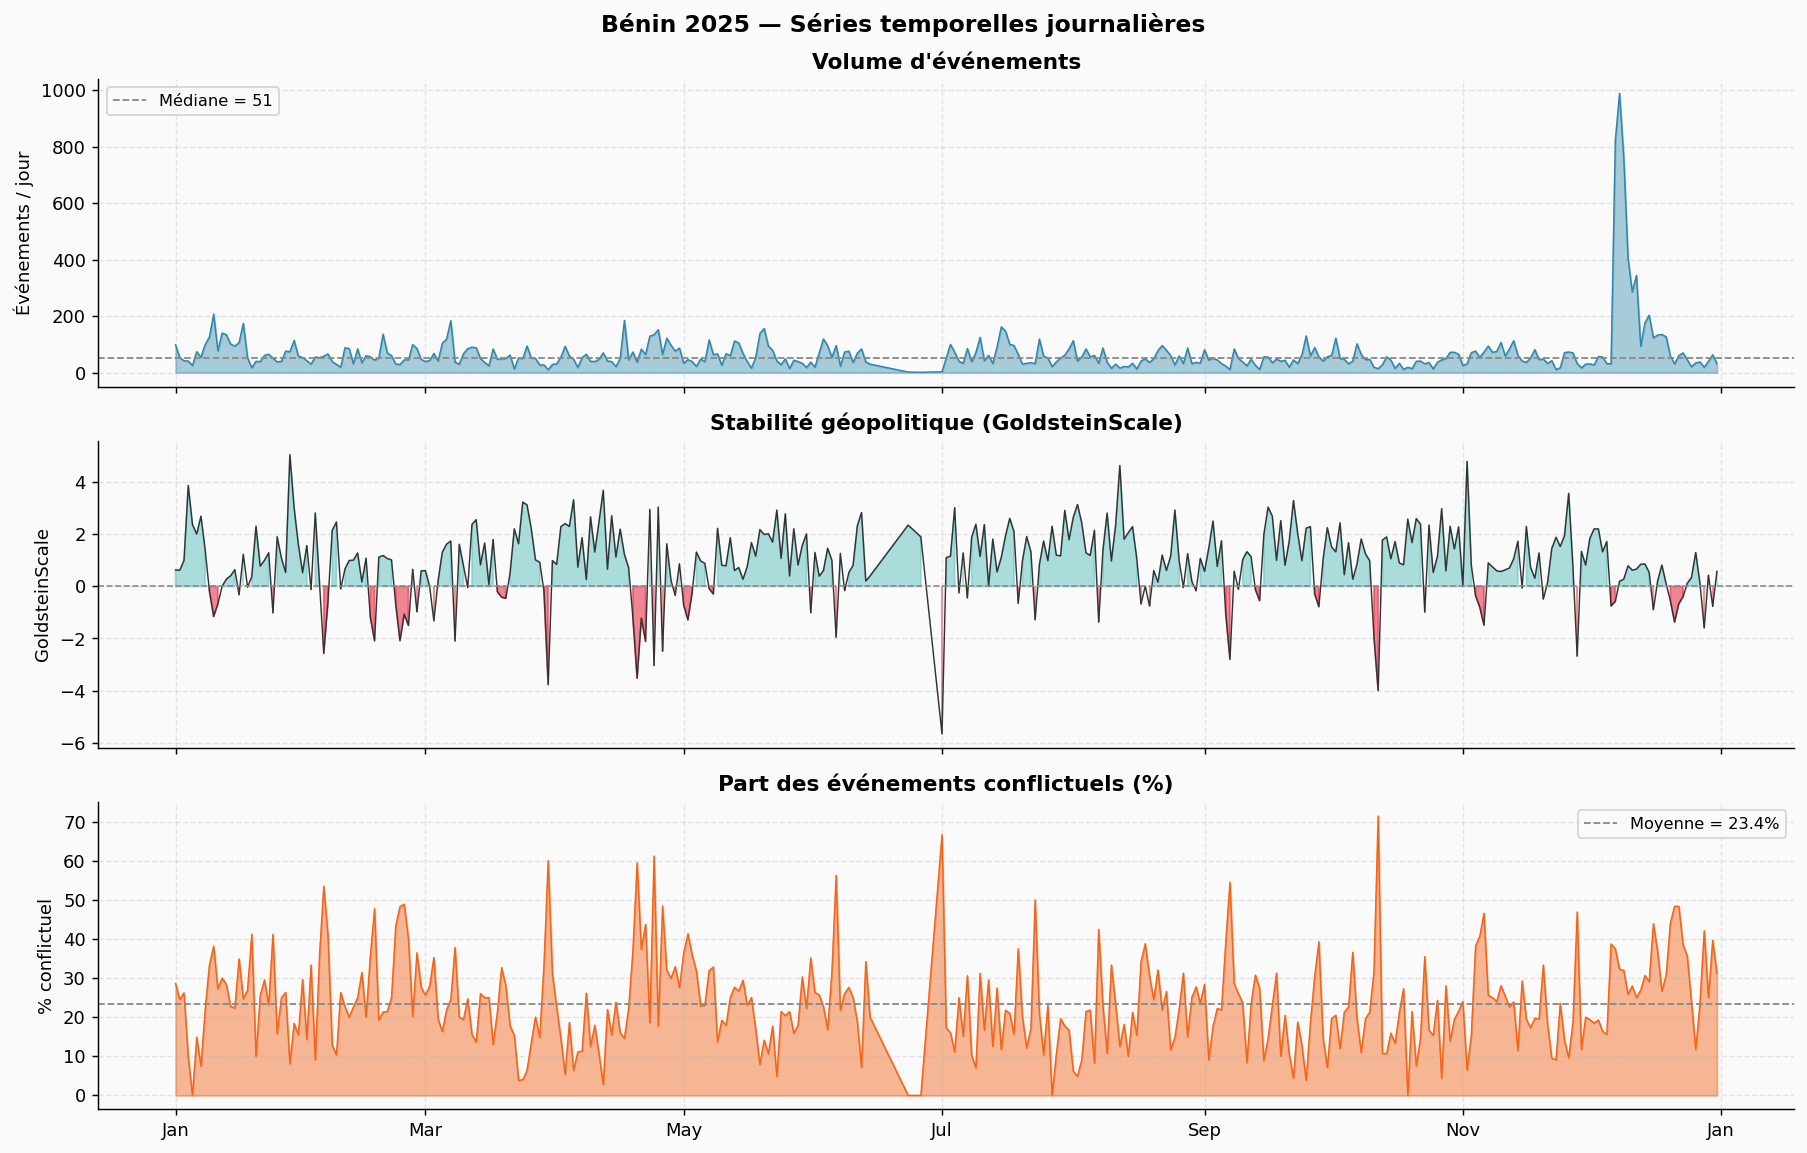

Figure sauvegardée : fig_anom_series.png


In [8]:
# ── Visualisation de la série brute 
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Bénin 2025 — Séries temporelles journalières', fontweight='bold', fontsize=13)

# Volume
axes[0].fill_between(daily['date'], daily['n_events'],
                     color=COLORS['normal'], alpha=0.4)
axes[0].plot(daily['date'], daily['n_events'],
             color=COLORS['normal'], linewidth=0.8)
axes[0].axhline(daily['n_events'].median(), color='#888',
                linestyle='--', linewidth=1, label=f"Médiane = {daily['n_events'].median():.0f}")
axes[0].set_ylabel("Événements / jour")
axes[0].set_title("Volume d'événements", fontweight='bold')
axes[0].legend(fontsize=9)

# GoldsteinScale
axes[1].fill_between(daily['date'], 0, daily['goldstein'],
                     where=daily['goldstein'] >= 0,
                     color=COLORS['goldstein'], alpha=0.5)
axes[1].fill_between(daily['date'], 0, daily['goldstein'],
                     where=daily['goldstein'] < 0,
                     color=COLORS['coup'], alpha=0.5)
axes[1].plot(daily['date'], daily['goldstein'], color='#333', linewidth=0.8)
axes[1].axhline(0, color='#888', linestyle='--', linewidth=0.9)
axes[1].set_ylabel("GoldsteinScale")
axes[1].set_title("Stabilité géopolitique (GoldsteinScale)", fontweight='bold')

# % conflit
axes[2].fill_between(daily['date'], daily['pct_conflict'],
                     color=COLORS['anomaly'], alpha=0.45)
axes[2].plot(daily['date'], daily['pct_conflict'],
             color=COLORS['anomaly'], linewidth=0.8)
axes[2].axhline(daily['pct_conflict'].mean(), color='#888',
                linestyle='--', linewidth=1,
                label=f"Moyenne = {daily['pct_conflict'].mean():.1f}%")
axes[2].set_ylabel("% conflictuel")
axes[2].set_title("Part des événements conflictuels (%)", fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.tight_layout()
plt.savefig('fig_anom_series.png', bbox_inches='tight', dpi=130)
plt.show()
print("Figure sauvegardée : fig_anom_series.png")


## 3. Méthode 1 : Z-score global <a id='3'></a>

Le **Z-score global** mesure l'écart d'un jour à la moyenne annuelle,  
exprimé en nombre d'écarts-types :

$$z_i = \frac{x_i - \bar{x}}{\sigma}$$

- $|z| > 2$ → **signal** (valeur inhabituelle)
- $|z| > 3$ → **anomalie forte** (probabilité < 0.3% sous distribution normale)

> ⚠️ **Limite :** sensible à la présence de valeurs extrêmes qui gonflent l'écart-type global.


In [9]:
# ── Calcul Z-score global
daily['z_global'] = ((daily['n_events'] - daily['n_events'].mean())
                     / daily['n_events'].std())

seuil_signal  = 2.0
seuil_anomaly = 3.0

daily['label_z_global'] = 'Normal'
daily.loc[daily['z_global'] > seuil_signal,  'label_z_global'] = 'Signal'
daily.loc[daily['z_global'] > seuil_anomaly, 'label_z_global'] = 'Anomalie'

# Résumé
print("=== Z-score global — Résultats ===")
print(f"Seuil signal   (|z| > {seuil_signal}) : {(daily['z_global'] > seuil_signal).sum()} jours")
print(f"Seuil anomalie (|z| > {seuil_anomaly}) : {(daily['z_global'] > seuil_anomaly).sum()} jours")
print()
print("Jours classés 'Anomalie' :")
print(daily[daily['label_z_global']=='Anomalie']
      [['date','n_events','z_global','goldstein','tone','pct_conflict']]
      .to_string(index=False))


=== Z-score global — Résultats ===
Seuil signal   (|z| > 2.0) : 6 jours
Seuil anomalie (|z| > 3.0) : 5 jours

Jours classés 'Anomalie' :
      date  n_events  z_global  goldstein      tone  pct_conflict
2025-12-07       822  8.750029  -0.579684 -2.615465     37.469586
2025-12-08       989 10.688758   0.192720 -2.854544     32.254803
2025-12-09       760  8.030261   0.275526 -2.665553     31.973684
2025-12-10       406  3.920620   0.786207 -3.289024     25.862069
2025-12-12       344  3.200853   0.659012 -1.755805     25.000000


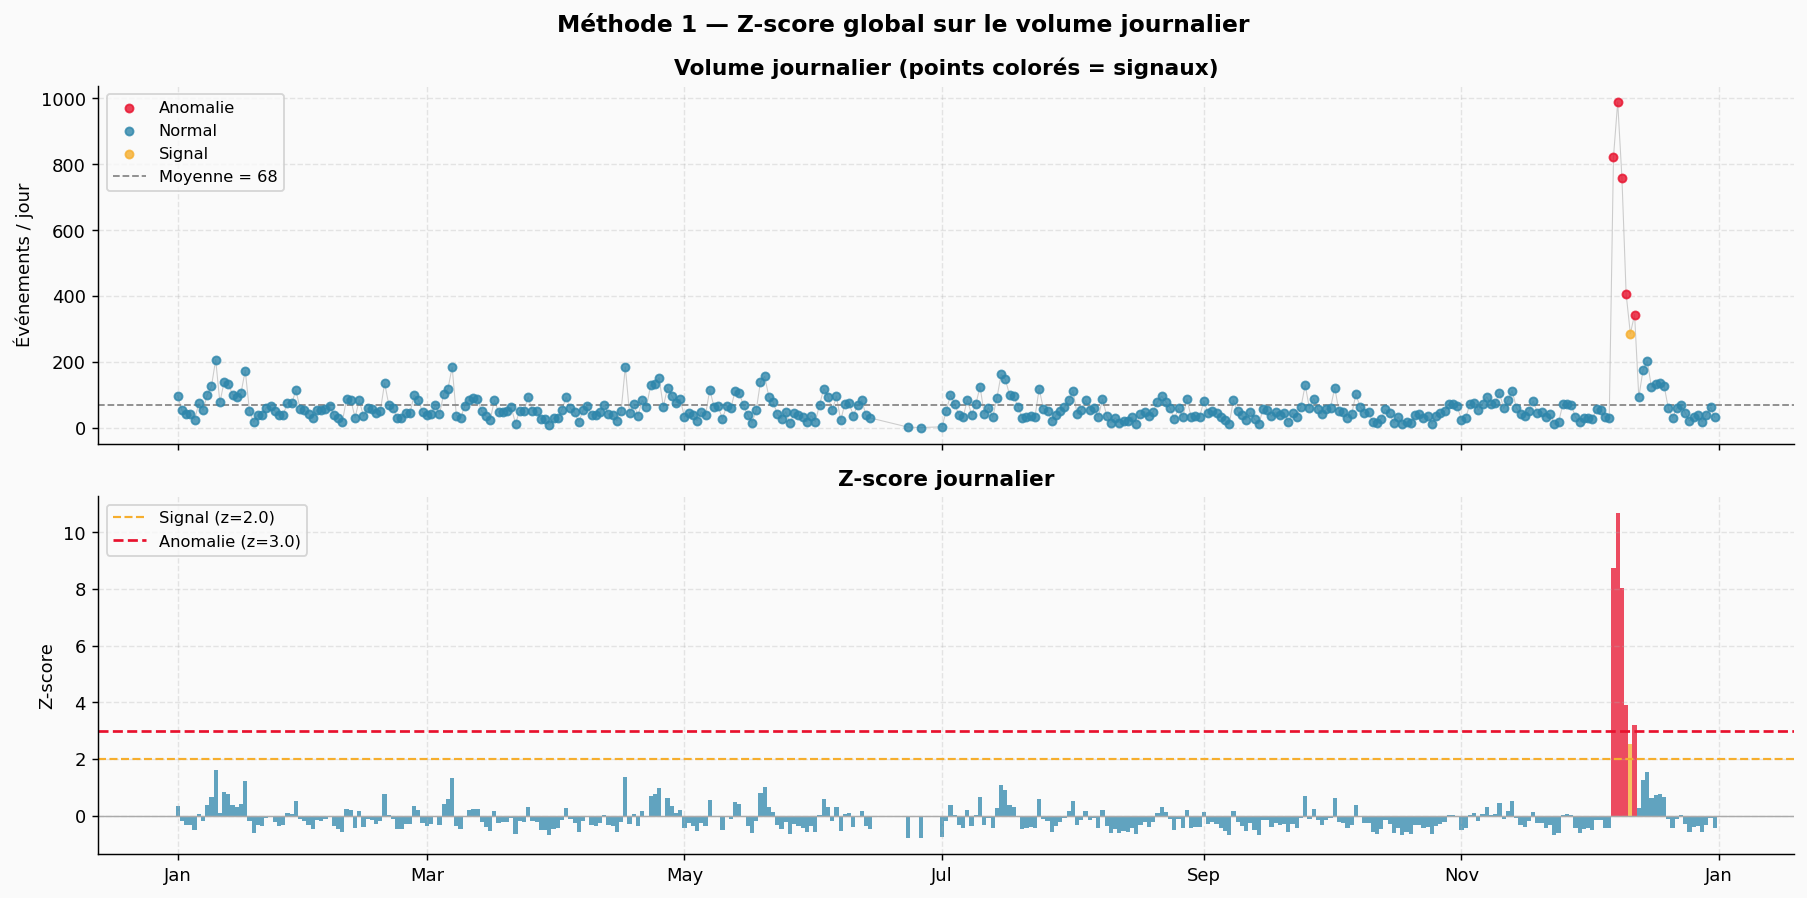

Figure sauvegardée : fig_anom_zscore_global.png


In [10]:
# ── Visualisation Z-score global 
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle('Méthode 1 — Z-score global sur le volume journalier',
             fontweight='bold', fontsize=13)

# Série avec couleurs par label
color_map = {'Normal': COLORS['normal'], 'Signal': COLORS['warning'],
             'Anomalie': COLORS['coup']}

for label, grp in daily.groupby('label_z_global'):
    axes[0].scatter(grp['date'], grp['n_events'],
                    c=color_map[label], s=20, label=label, zorder=3, alpha=0.8)
axes[0].plot(daily['date'], daily['n_events'], color='#ccc', linewidth=0.6, zorder=1)
axes[0].axhline(daily['n_events'].mean(), color='#888', linestyle='--',
                linewidth=1, label=f"Moyenne = {daily['n_events'].mean():.0f}")
axes[0].set_ylabel("Événements / jour")
axes[0].set_title("Volume journalier (points colorés = signaux)", fontweight='bold')
axes[0].legend(fontsize=9)

# Z-score lui-même
axes[1].bar(daily['date'], daily['z_global'],
            color=[color_map[l] for l in daily['label_z_global']],
            width=1.0, alpha=0.75)
axes[1].axhline(seuil_signal,  color=COLORS['warning'], linestyle='--',
                linewidth=1.2, label=f'Signal (z={seuil_signal})')
axes[1].axhline(seuil_anomaly, color=COLORS['coup'], linestyle='--',
                linewidth=1.5, label=f'Anomalie (z={seuil_anomaly})')
axes[1].axhline(0, color='#aaa', linewidth=0.8)
axes[1].set_ylabel("Z-score")
axes[1].set_title("Z-score journalier", fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.tight_layout()
plt.savefig('fig_anom_zscore_global.png', bbox_inches='tight', dpi=130)
plt.show()
print("Figure sauvegardée : fig_anom_zscore_global.png")


## 4. Méthode 2 : Z-score sur fenêtre glissante (rolling 14j) <a id='4'></a>

Le **Z-score local (rolling)** compare chaque jour à sa **fenêtre contextuelle de 14 jours**,  
ce qui capture mieux les tendances locales et les saisonnalités courtes :

$$z_i^{roll} = \frac{x_i - \bar{x}_{14j}}{\sigma_{14j}}$$

>  **Avantage :** plus robuste aux variations saisonnières et aux tendances graduelles.  
>  **Limite :** moins sensible aux anomalies lentes et progressives.


In [11]:
# ── Calcul rolling 14j 
daily['roll_mean'] = daily['n_events'].rolling(14, min_periods=5).mean()
daily['roll_std']  = daily['n_events'].rolling(14, min_periods=5).std()
daily['z_roll']    = ((daily['n_events'] - daily['roll_mean'])
                      / (daily['roll_std'] + 1e-6))

seuil_roll = 2.0

daily['label_z_roll'] = 'Normal'
daily.loc[daily['z_roll'] > seuil_roll,       'label_z_roll'] = 'Signal'
daily.loc[daily['z_roll'] > seuil_roll * 1.5, 'label_z_roll'] = 'Anomalie'

print("=== Z-score rolling 14j — Résultats ===")
print(f"Seuil signal   (z > {seuil_roll})   : {(daily['z_roll'] > seuil_roll).sum()} jours")
print(f"Seuil anomalie (z > {seuil_roll*1.5}) : {(daily['z_roll'] > seuil_roll*1.5).sum()} jours")
print()
print("Top 10 jours par z_roll :")
print(daily.nlargest(10, 'z_roll')
      [['date','n_events','roll_mean','z_roll','goldstein','tone','pct_conflict']]
      .round(2).to_string(index=False))


=== Z-score rolling 14j — Résultats ===
Seuil signal   (z > 2.0)   : 12 jours
Seuil anomalie (z > 3.0) : 2 jours

Top 10 jours par z_roll :
      date  n_events  roll_mean  z_roll  goldstein  tone  pct_conflict
2025-12-07       822      97.50    3.46      -0.58 -2.62         37.47
2025-04-17       185      55.29    3.24       1.23  2.28         14.59
2025-09-25       130      46.50    2.98       2.23  1.34          3.85
2025-12-08       989     166.93    2.61       0.19 -2.85         32.25
2025-03-07       184      69.86    2.59       1.74 -2.55         24.46
2025-02-19       136      58.86    2.47       1.18 -0.07         21.32
2025-08-22        96      38.21    2.40       1.20 -2.22         21.88
2025-07-15       162      71.79    2.37       1.11 -0.24         11.73
2025-01-10       207      82.00    2.31      -1.16 -3.34         38.16
2025-10-29        72      32.64    2.28       2.31  0.45         13.89


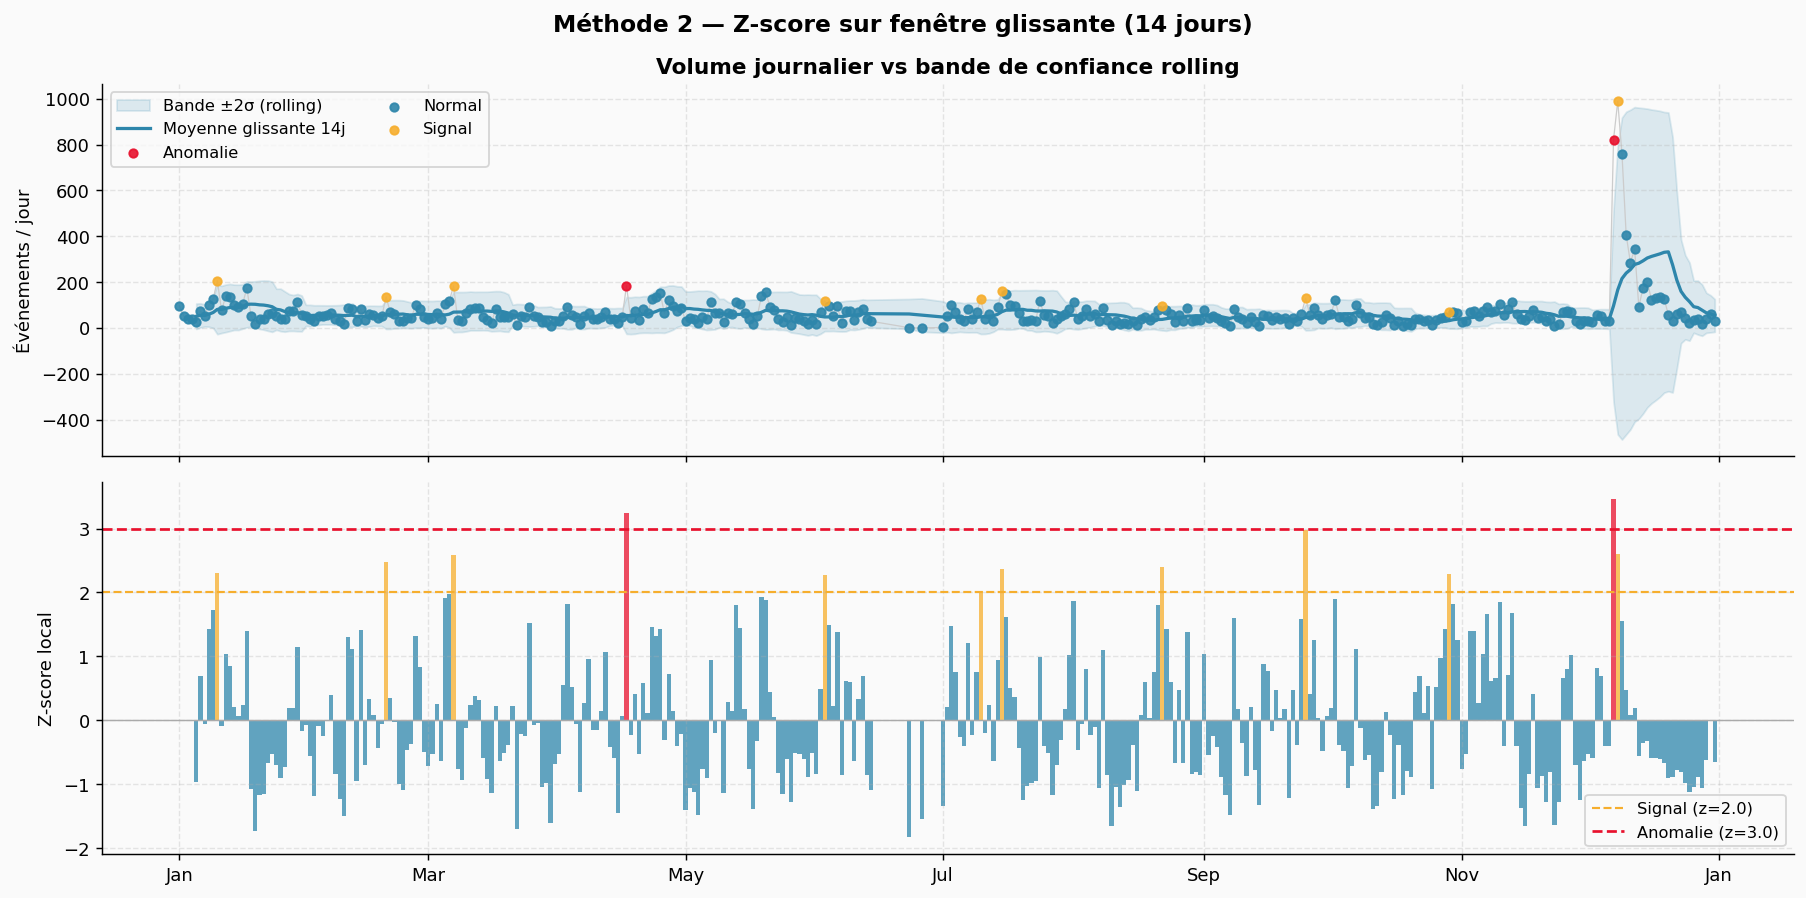

Figure sauvegardée : fig_anom_zscore_roll.png


In [12]:
# ── Visualisation rolling
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle('Méthode 2 — Z-score sur fenêtre glissante (14 jours)',
             fontweight='bold', fontsize=13)

# Volume + bande de confiance rolling
axes[0].fill_between(daily['date'],
                     daily['roll_mean'] - 2*daily['roll_std'],
                     daily['roll_mean'] + 2*daily['roll_std'],
                     color=COLORS['normal'], alpha=0.15, label='Bande ±2σ (rolling)')
axes[0].plot(daily['date'], daily['roll_mean'],
             color=COLORS['normal'], linewidth=1.8, label='Moyenne glissante 14j')
axes[0].plot(daily['date'], daily['n_events'],
             color='#ccc', linewidth=0.7, zorder=1)

color_map = {'Normal': COLORS['normal'], 'Signal': COLORS['warning'],
             'Anomalie': COLORS['coup']}
for label, grp in daily.groupby('label_z_roll'):
    axes[0].scatter(grp['date'], grp['n_events'],
                    c=color_map[label], s=22, label=label, zorder=4, alpha=0.9)

axes[0].set_ylabel("Événements / jour")
axes[0].set_title("Volume journalier vs bande de confiance rolling", fontweight='bold')
axes[0].legend(fontsize=9, ncol=2)

# Z-roll
axes[1].bar(daily['date'], daily['z_roll'],
            color=[color_map[l] for l in daily['label_z_roll']],
            width=1.0, alpha=0.75)
axes[1].axhline(seuil_roll,       color=COLORS['warning'], linestyle='--',
                linewidth=1.2, label=f'Signal (z={seuil_roll})')
axes[1].axhline(seuil_roll * 1.5, color=COLORS['coup'], linestyle='--',
                linewidth=1.5, label=f'Anomalie (z={seuil_roll*1.5})')
axes[1].axhline(0, color='#aaa', linewidth=0.8)
axes[1].set_ylabel("Z-score local")
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.tight_layout()
plt.savefig('fig_anom_zscore_roll.png', bbox_inches='tight', dpi=130)
plt.show()
print("Figure sauvegardée : fig_anom_zscore_roll.png")


## 5. Méthode 3 : Score composite multi-dimensionnel <a id='5'></a>

Les deux méthodes précédentes se basent uniquement sur le **volume**.  
Le score composite intègre **4 dimensions** pour capturer les anomalies qualitatives  
(un jour peut être anormal même sans pic de volume) :

| Dimension | Poids | Logique |
|-----------|-------|---------|
| Volume (z_roll) | 50% | Pic de couverture médiatique |
| % conflictuel | 25% | Hausse des événements violents |
| Ton négatif (AvgTone) | 15% | Détérioration du discours |
| Événements violents (Fight+Assault) | 10% | Actions physiques réelles |


In [13]:
# ── Standardisation des dimensions
def zscore(series):
    return (series - series.mean()) / (series.std() + 1e-9)

daily['z_vol']      = daily['z_roll'].clip(0)           # volume anormal (positif)
daily['z_conflict'] = zscore(daily['pct_conflict'])
daily['z_tone_neg'] = zscore(-daily['tone'])             # ton négatif = anomalie
daily['z_violence'] = zscore(daily['n_fight'] + daily['n_assault'])

# Score composite pondéré
daily['score_composite'] = (
    0.50 * daily['z_vol']      +
    0.25 * daily['z_conflict'] +
    0.15 * daily['z_tone_neg'] +
    0.10 * daily['z_violence']
)

# Seuils
seuil_comp_signal  = daily['score_composite'].mean() + 1.5 * daily['score_composite'].std()
seuil_comp_anomaly = daily['score_composite'].mean() + 2.5 * daily['score_composite'].std()

daily['label_composite'] = 'Normal'
daily.loc[daily['score_composite'] > seuil_comp_signal,  'label_composite'] = 'Signal'
daily.loc[daily['score_composite'] > seuil_comp_anomaly, 'label_composite'] = 'Anomalie'

print("=== Score composite — Résultats ===")
print(f"Seuil signal   : {seuil_comp_signal:.3f}")
print(f"Seuil anomalie : {seuil_comp_anomaly:.3f}")
print()
print("Top 10 jours par score composite :")
cols = ['date','score_composite','n_events','pct_conflict','tone','n_fight','n_assault']
print(daily.nlargest(10, 'score_composite')[cols].round(3).to_string(index=False))


=== Score composite — Résultats ===
Seuil signal   : 1.021
Seuil anomalie : 1.567

Top 10 jours par score composite :
      date  score_composite  n_events  pct_conflict    tone  n_fight  n_assault
2025-12-07            3.117       822        37.470  -2.615       74         24
2025-12-08            2.568       989        32.255  -2.855       61         34
2025-04-24            2.285       134        61.194  -6.404       38          5
2025-01-10            2.159       207        38.164  -3.338       50          4
2025-06-06            1.851        96        56.250  -5.519       15          0
2025-07-01            1.669         3        66.667 -10.935        2          0
2025-12-09            1.636       760        31.974  -2.666       40         18
2025-01-09            1.429       126        33.333  -1.953       27          5
2025-03-07            1.419       184        24.457  -2.550        3          0
2025-10-12            1.348        14        71.429  -5.380        1          2


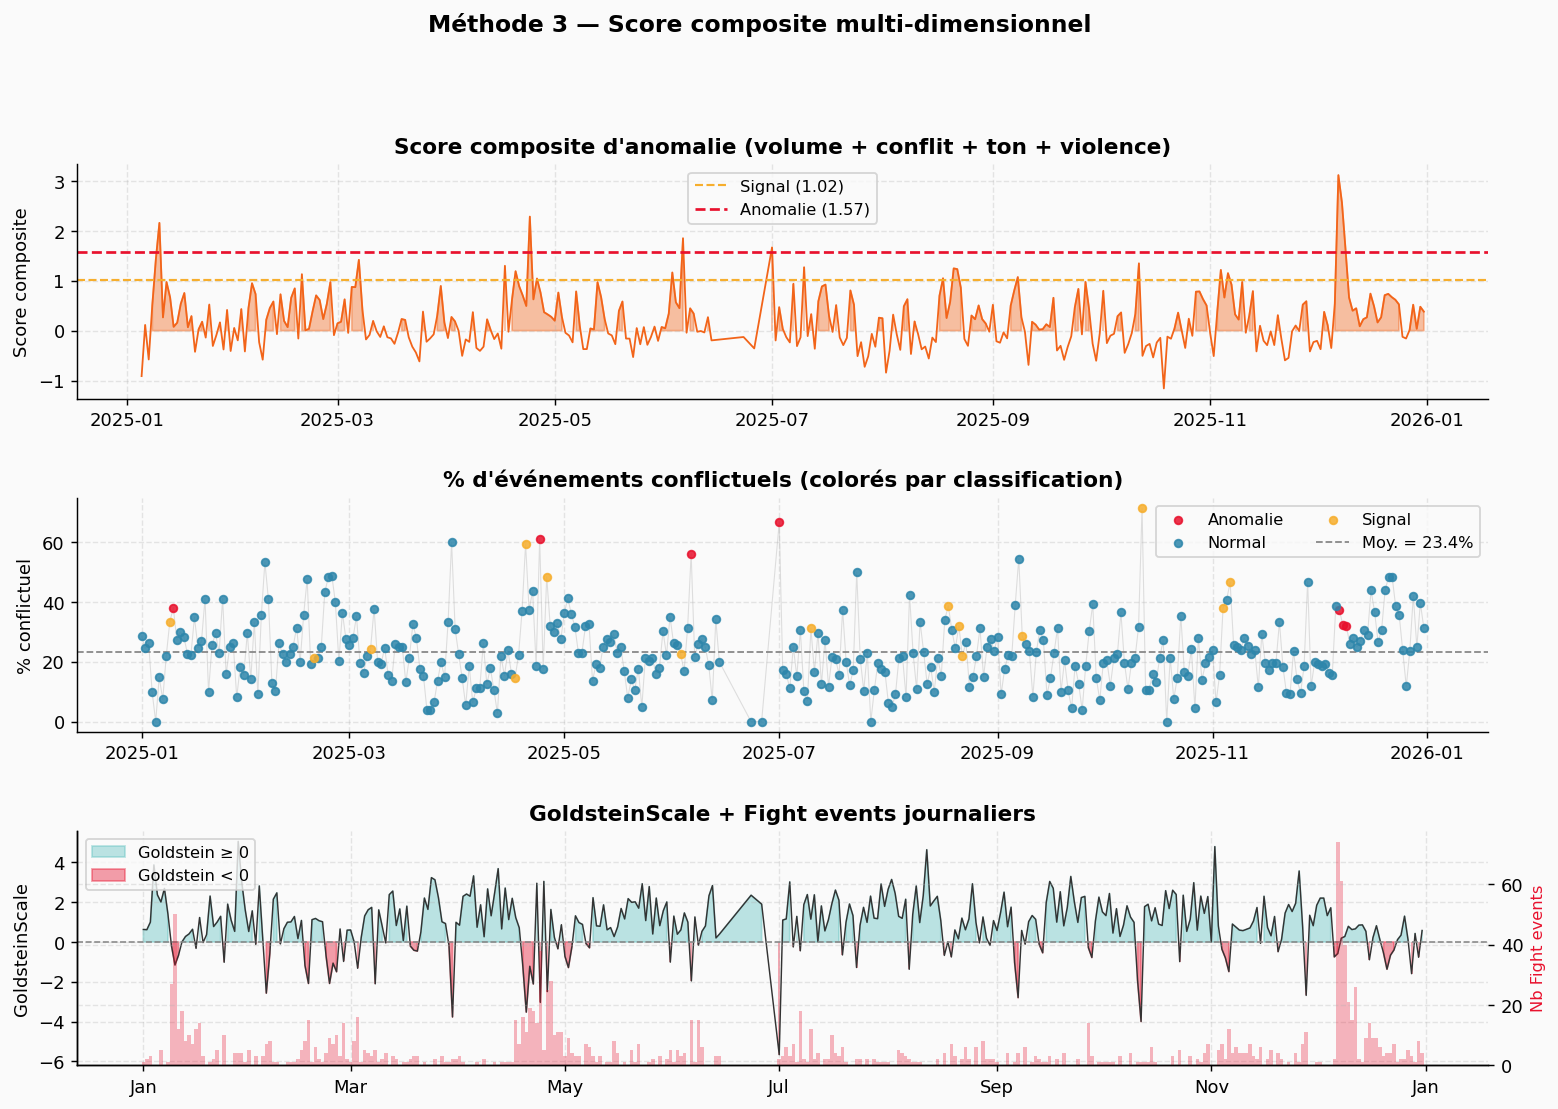

Figure sauvegardée : fig_anom_composite.png


In [14]:
# ── Visualisation score composite
fig = plt.figure(figsize=(14, 9))
gs  = GridSpec(3, 1, figure=fig, hspace=0.42)

color_map = {'Normal': COLORS['normal'], 'Signal': COLORS['warning'],
             'Anomalie': COLORS['coup']}

# Score composite
ax1 = fig.add_subplot(gs[0])
ax1.fill_between(daily['date'], 0, daily['score_composite'],
                 where=daily['score_composite'] > 0,
                 color=COLORS['anomaly'], alpha=0.4)
ax1.plot(daily['date'], daily['score_composite'],
         color=COLORS['anomaly'], linewidth=1.0)
ax1.axhline(seuil_comp_signal,  color=COLORS['warning'], linestyle='--',
            linewidth=1.2, label=f'Signal ({seuil_comp_signal:.2f})')
ax1.axhline(seuil_comp_anomaly, color=COLORS['coup'], linestyle='--',
            linewidth=1.5, label=f'Anomalie ({seuil_comp_anomaly:.2f})')
ax1.set_ylabel("Score composite")
ax1.set_title("Score composite d'anomalie (volume + conflit + ton + violence)",
              fontweight='bold')
ax1.legend(fontsize=9)

# % conflit
ax2 = fig.add_subplot(gs[1])
for label, grp in daily.groupby('label_composite'):
    ax2.scatter(grp['date'], grp['pct_conflict'],
                c=color_map[label], s=18, label=label, zorder=3, alpha=0.85)
ax2.plot(daily['date'], daily['pct_conflict'], color='#ddd', linewidth=0.6, zorder=1)
ax2.axhline(daily['pct_conflict'].mean(), color='#888', linestyle='--',
            linewidth=1, label=f"Moy. = {daily['pct_conflict'].mean():.1f}%")
ax2.set_ylabel("% conflictuel")
ax2.set_title("% d'événements conflictuels (colorés par classification)", fontweight='bold')
ax2.legend(fontsize=9, ncol=2)

# GoldsteinScale + Fight
ax3 = fig.add_subplot(gs[2])
ax3.fill_between(daily['date'], 0, daily['goldstein'],
                 where=daily['goldstein'] >= 0,
                 color=COLORS['goldstein'], alpha=0.4, label='Goldstein ≥ 0')
ax3.fill_between(daily['date'], 0, daily['goldstein'],
                 where=daily['goldstein'] < 0,
                 color=COLORS['coup'], alpha=0.4, label='Goldstein < 0')
ax3.plot(daily['date'], daily['goldstein'], color='#333', linewidth=0.8)
ax3_r = ax3.twinx()
ax3_r.bar(daily['date'], daily['n_fight'],
          color=COLORS['coup'], alpha=0.3, width=1.0, label='Fight events')
ax3_r.set_ylabel("Nb Fight events", color=COLORS['coup'], fontsize=9)
ax3.axhline(0, color='#888', linewidth=0.9, linestyle='--')
ax3.set_ylabel("GoldsteinScale")
ax3.set_title("GoldsteinScale + Fight events journaliers", fontweight='bold')
ax3.legend(fontsize=9, loc='upper left')
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

fig.suptitle('Méthode 3 — Score composite multi-dimensionnel',
             fontweight='bold', fontsize=13, y=1.01)
plt.savefig('fig_anom_composite.png', bbox_inches='tight', dpi=130)
plt.show()
print("Figure sauvegardée : fig_anom_composite.png")


## 6. Synthèse des anomalies détectées <a id='6'></a>

On consolide les trois méthodes : un jour est retenu si détecté par **au moins 2 méthodes sur 3**.


In [15]:
# ── Table de synthèse des 3 méthodes
daily['flag_m1'] = (daily['z_global'] > 3).astype(int)
daily['flag_m2'] = (daily['z_roll']   > seuil_roll).astype(int)
daily['flag_m3'] = (daily['score_composite'] > seuil_comp_signal).astype(int)
daily['n_flags'] = daily['flag_m1'] + daily['flag_m2'] + daily['flag_m3']

anomalies = daily[daily['n_flags'] >= 2].sort_values('score_composite', ascending=False)

print(f"Jours détectés par >= 2 méthodes : {len(anomalies)}")
print()
cols_show = ['date','n_events','z_global','z_roll','score_composite',
             'goldstein','tone','pct_conflict','n_fight','n_assault','n_flags']
print(anomalies[cols_show].round(2).to_string(index=False))


Jours détectés par >= 2 méthodes : 10

      date  n_events  z_global  z_roll  score_composite  goldstein  tone  pct_conflict  n_fight  n_assault  n_flags
2025-12-07       822      8.75    3.46             3.12      -0.58 -2.62         37.47       74         24        3
2025-12-08       989     10.69    2.61             2.57       0.19 -2.85         32.25       61         34        3
2025-01-10       207      1.61    2.31             2.16      -1.16 -3.34         38.16       50          4        2
2025-12-09       760      8.03    1.55             1.64       0.28 -2.67         31.97       40         18        2
2025-03-07       184      1.34    2.59             1.42       1.74 -2.55         24.46        3          0        2
2025-04-17       185      1.35    3.24             1.30       1.23  2.28         14.59       15          2        2
2025-07-10       125      0.66    2.02             1.27       1.15 -1.28         31.20       12          0        2
2025-08-22        96      0.32   

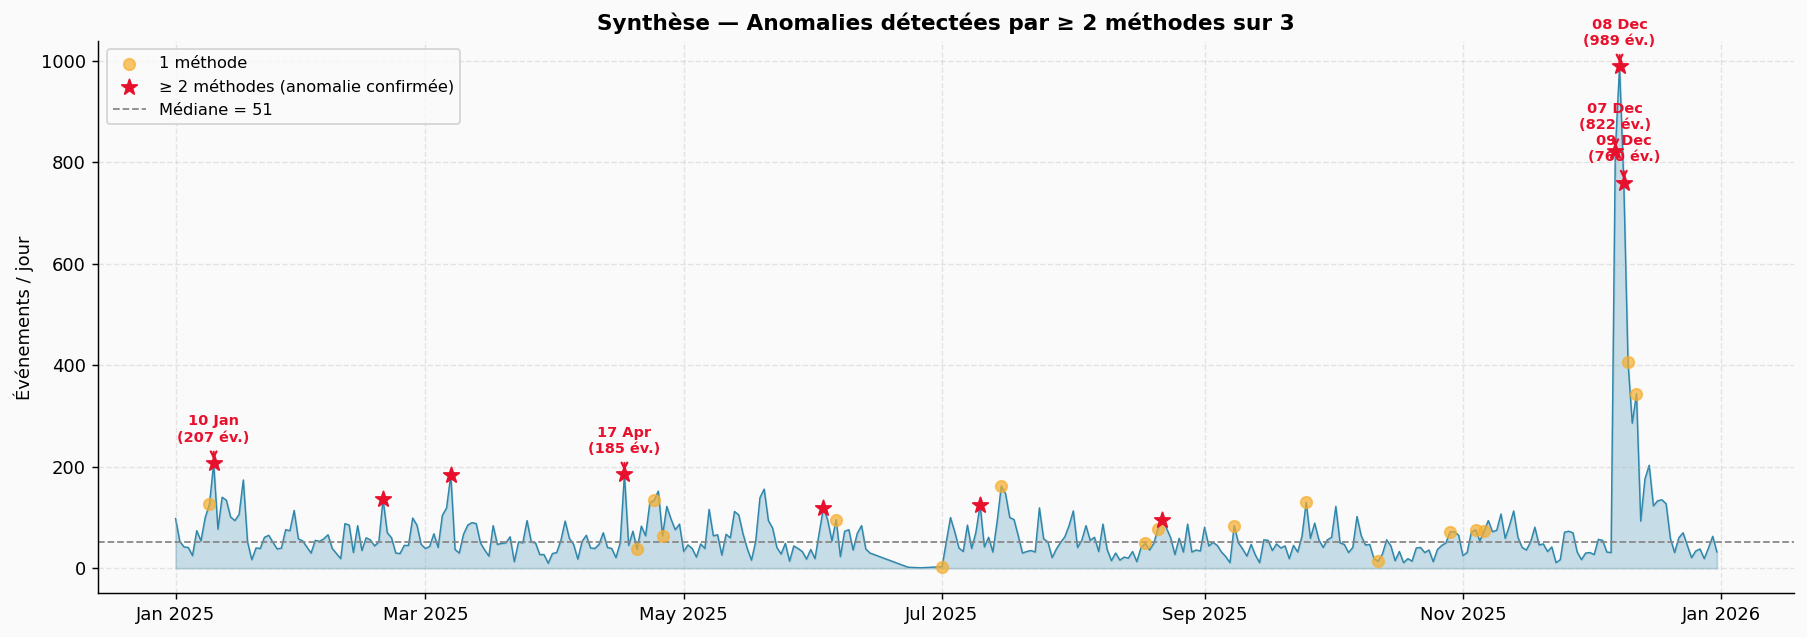

Figure sauvegardée : fig_anom_synthese.png


In [16]:
# ── Visualisation synthèse
fig, ax = plt.subplots(figsize=(14, 5))

# Série de fond
ax.fill_between(daily['date'], daily['n_events'],
                color=COLORS['normal'], alpha=0.25)
ax.plot(daily['date'], daily['n_events'],
        color=COLORS['normal'], linewidth=0.8, zorder=1)

# Jours signalés par 1 méthode
d1 = daily[daily['n_flags'] == 1]
ax.scatter(d1['date'], d1['n_events'], color=COLORS['warning'],
           s=40, zorder=3, label='1 méthode', marker='o', alpha=0.7)

# Jours signalés par 2+ méthodes
d2 = daily[daily['n_flags'] >= 2]
ax.scatter(d2['date'], d2['n_events'], color=COLORS['coup'],
           s=80, zorder=4, label='≥ 2 méthodes (anomalie confirmée)', marker='*')

# Annotations des anomalies majeures
for _, row in anomalies.nlargest(5, 'n_events').iterrows():
    ax.annotate(
        f"{row['date'].strftime('%d %b')}\n({int(row['n_events'])} év.)",
        xy=(row['date'], row['n_events']),
        xytext=(0, 12), textcoords='offset points',
        ha='center', fontsize=8, fontweight='bold', color=COLORS['coup'],
        arrowprops=dict(arrowstyle='->', color=COLORS['coup'], lw=1.2)
    )

ax.axhline(daily['n_events'].median(), color='#888', linestyle='--',
           linewidth=1, label=f"Médiane = {daily['n_events'].median():.0f}")
ax.set_title('Synthèse — Anomalies détectées par ≥ 2 méthodes sur 3',
             fontweight='bold', fontsize=12)
ax.set_ylabel("Événements / jour")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig('fig_anom_synthese.png', bbox_inches='tight', dpi=130)
plt.show()
print("Figure sauvegardée : fig_anom_synthese.png")


## 7. Zoom : le pic du 7-8 décembre 2025 <a id='7'></a>

### Contexte identifié
Les URLs collectées lors du pic révèlent le titre explicite :  
**"Benin coup thwarted by loyalist troops — President Talon tells nation"**  
(Sources : ghanamma.com, chimpreports.com, citizen.co.za, spacewar.com/AFP, bbc.com…)

Il s'agit d'une **tentative de coup d'État** déjouée par les forces loyalistes béninoises  
les 7-8 décembre 2025.


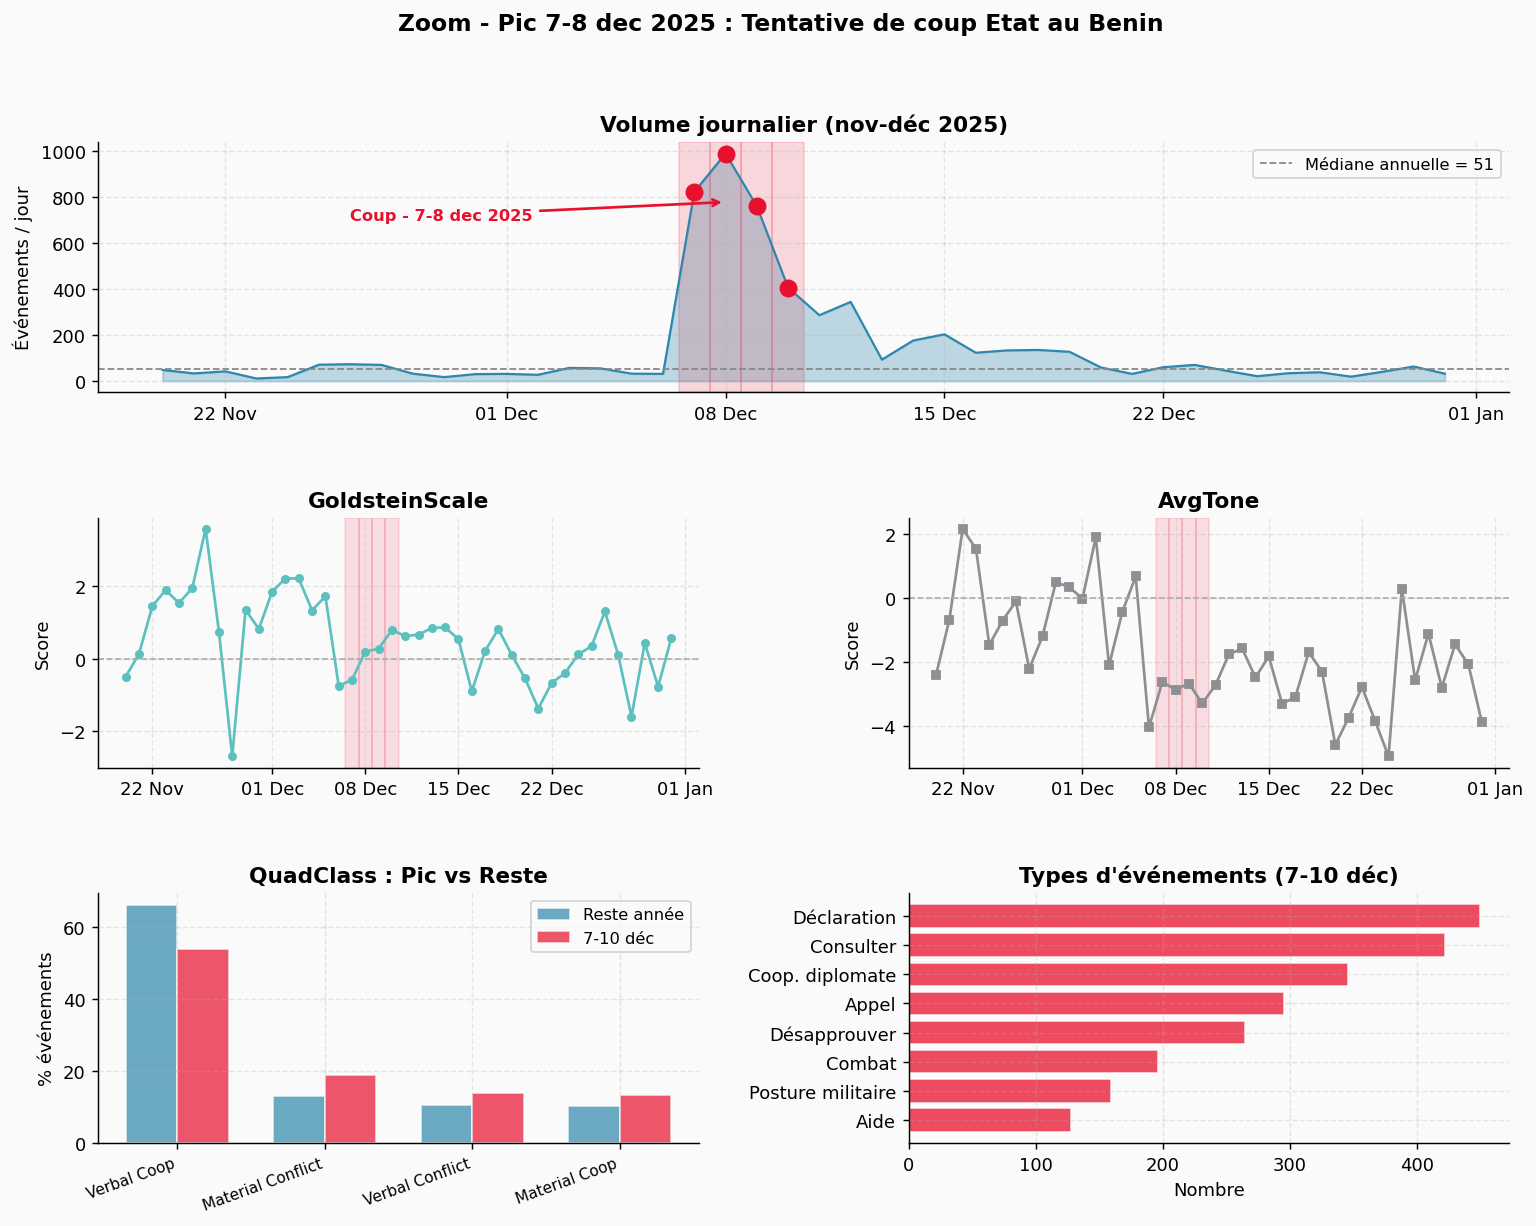

Figure sauvegardée : fig_anom_zoom_dec.png


In [17]:
# ── Zoom sur la fenêtre 1–15 décembre
dec_window = daily[daily['date'].between('2025-11-20','2025-12-31')].copy()
peak_days  = ['2025-12-07','2025-12-08','2025-12-09','2025-12-10']

fig = plt.figure(figsize=(14, 10))
gs  = GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.35)
fig.suptitle("Zoom - Pic 7-8 dec 2025 : Tentative de coup Etat au Benin",
             fontweight='bold', fontsize=13)

# 1. Volume zoomed
ax1 = fig.add_subplot(gs[0, :])
ax1.fill_between(dec_window['date'], dec_window['n_events'],
                 color=COLORS['normal'], alpha=0.3)
ax1.plot(dec_window['date'], dec_window['n_events'],
         color=COLORS['normal'], linewidth=1.2)
for d in peak_days:
    dt = pd.to_datetime(d)
    val = dec_window.loc[dec_window['date']==dt,'n_events']
    if len(val):
        ax1.axvspan(dt - pd.Timedelta('0.5d'), dt + pd.Timedelta('0.5d'),
                    color=COLORS['coup'], alpha=0.15)
        ax1.scatter([dt], val.values, color=COLORS['coup'], s=80, zorder=5)

ax1.axhline(daily['n_events'].median(), color='#888', linestyle='--',
            linewidth=1, label=f"Médiane annuelle = {daily['n_events'].median():.0f}")
ax1.annotate("Coup - 7-8 dec 2025",
             xy=(pd.Timestamp('2025-12-08'), 778),
             xytext=(pd.Timestamp('2025-11-26'), 700),
             fontsize=9, fontweight='bold', color=COLORS['coup'],
             arrowprops=dict(arrowstyle='->', color=COLORS['coup'], lw=1.5))
ax1.set_title('Volume journalier (nov-déc 2025)', fontweight='bold')
ax1.set_ylabel("Événements / jour")
ax1.legend(fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

# 2. GoldsteinScale zoomed
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(dec_window['date'], dec_window['goldstein'],
         color=COLORS['goldstein'], linewidth=1.5, marker='o', markersize=4)
ax2.axhline(0, color='#aaa', linestyle='--', linewidth=0.9)
for d in peak_days:
    ax2.axvspan(pd.to_datetime(d) - pd.Timedelta('0.5d'),
                pd.to_datetime(d) + pd.Timedelta('0.5d'),
                color=COLORS['coup'], alpha=0.12)
ax2.set_title('GoldsteinScale', fontweight='bold')
ax2.set_ylabel("Score")
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

# 3. AvgTone zoomed
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(dec_window['date'], dec_window['tone'],
         color=COLORS['tone'], linewidth=1.5, marker='s', markersize=4)
ax3.axhline(0, color='#aaa', linestyle='--', linewidth=0.9)
for d in peak_days:
    ax3.axvspan(pd.to_datetime(d) - pd.Timedelta('0.5d'),
                pd.to_datetime(d) + pd.Timedelta('0.5d'),
                color=COLORS['coup'], alpha=0.12)
ax3.set_title('AvgTone', fontweight='bold')
ax3.set_ylabel("Score")
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

# 4. QuadClass du pic vs reste
ax4 = fig.add_subplot(gs[2, 0])
QC_MAP = {1:'Verbal Coop', 2:'Material Coop', 3:'Verbal Conflict', 4:'Material Conflict'}
peak_df = df[df['date'].between('2025-12-07','2025-12-10')]
rest_df = df[~df['date'].between('2025-12-07','2025-12-10')]
peak_qc = peak_df['QuadClass'].map(QC_MAP).value_counts(normalize=True) * 100
rest_qc  = rest_df['QuadClass'].map(QC_MAP).value_counts(normalize=True) * 100
x = range(len(peak_qc))
w = 0.35
qc_colors = [COLORS['normal'], COLORS['goldstein'], COLORS['warning'], COLORS['coup']]
bars1 = ax4.bar([i-w/2 for i in x], rest_qc.reindex(peak_qc.index, fill_value=0),
                width=w, label='Reste année', color=COLORS['normal'], alpha=0.7, edgecolor='white')
bars2 = ax4.bar([i+w/2 for i in x], peak_qc,
                width=w, label='7-10 déc', color=COLORS['coup'], alpha=0.7, edgecolor='white')
ax4.set_xticks(list(x))
ax4.set_xticklabels(peak_qc.index, rotation=20, ha='right', fontsize=8.5)
ax4.set_title('QuadClass : Pic vs Reste', fontweight='bold')
ax4.set_ylabel("% événements")
ax4.legend(fontsize=9)

# 5. Top EventRootCode du pic
ax5 = fig.add_subplot(gs[2, 1])
EVROOT_MAP = {
    1:'Déclaration', 2:'Appel', 3:'Intent. coopérer', 4:'Consulter',
    5:'Coop. diplomate', 6:'Coop. matérielle', 7:'Aide', 8:'Céder',
    9:'Enquêter', 10:'Demander', 11:'Désapprouver', 12:'Rejeter',
    13:'Menacer', 14:'Protester', 15:'Posture militaire',
    16:'Réduire rel.', 17:'Contraindre', 18:'Assaut', 19:'Combat',
    20:'Violence de masse'
}
ev_peak = peak_df['EventRootCode'].map(EVROOT_MAP).value_counts().head(8)
ax5.barh(ev_peak.index[::-1], ev_peak.values[::-1],
         color=COLORS['coup'], alpha=0.75, edgecolor='white')
ax5.set_title('Types d\'événements (7-10 déc)', fontweight='bold')
ax5.set_xlabel("Nombre")

plt.savefig('fig_anom_zoom_dec.png', bbox_inches='tight', dpi=130)
plt.show()
print("Figure sauvegardée : fig_anom_zoom_dec.png")


In [18]:
# ── Profil comparatif chiffré : pic vs reste
peak_df = df[df['date'].between('2025-12-07','2025-12-10')]
rest_df  = df[~df['date'].between('2025-12-07','2025-12-10')]

print("=" * 62)
print("  PROFIL COMPARATIF — PIC 7-10 DÉC vs RESTE 2025")
print("=" * 62)
print(f"{'Indicateur':<30} {'Pic 7-10 déc':>14} {'Reste 2025':>14}")
print("-" * 62)
print(f"{'Volume (événements / jour)':<30} {2370/4:>14.0f} {(len(rest_df)/346):>14.0f}")
print(f"{'GoldsteinScale moyen':<30} {peak_df['GoldsteinScale'].mean():>14.3f} {rest_df['GoldsteinScale'].mean():>14.3f}")
print(f"{'AvgTone moyen':<30} {peak_df['AvgTone'].mean():>14.3f} {rest_df['AvgTone'].mean():>14.3f}")
print(f"{'% conflictuel':<30} {100*(peak_df['QuadClass'].isin([3,4])).mean():>13.1f}% {100*(rest_df['QuadClass'].isin([3,4])).mean():>13.1f}%")
print(f"{'Fight events / jour':<30} {peak_df[peak_df['EventRootCode']==19].shape[0]/4:>14.1f} {rest_df[rest_df['EventRootCode']==19].shape[0]/346:>14.1f}")
print(f"{'Assault events / jour':<30} {peak_df[peak_df['EventRootCode']==18].shape[0]/4:>14.1f} {rest_df[rest_df['EventRootCode']==18].shape[0]/346:>14.1f}")
print(f"{'Sources médias uniques':<30} {peak_df['domain'].nunique():>14} {rest_df['domain'].nunique():>14}")
print("=" * 62)


  PROFIL COMPARATIF — PIC 7-10 DÉC vs RESTE 2025
Indicateur                       Pic 7-10 déc     Reste 2025
--------------------------------------------------------------
Volume (événements / jour)                592             61
GoldsteinScale moyen                    0.082          0.942
AvgTone moyen                          -2.800         -1.008
% conflictuel                           32.8%          23.6%
Fight events / jour                      49.0            3.7
Assault events / jour                    19.8            0.8
Sources médias uniques                    434           1297


## 8. Interprétation et recommandations <a id='8'></a>


In [19]:
print("=" * 65)
print("  SYNTHÈSE — ANOMALIES DÉTECTÉES DANS GDELT BÉNIN 2025")
print("=" * 65)

print("""
 # ANOMALIE MAJEURE — 7-10 décembre 2025 (confirmée par 3/3 méthodes)
   Volume : 778 événements le 8 déc (vs médiane de 48/j → ×16)
   Nature : Tentative de coup d'État déjouée par les forces loyalistes
   Signal : GoldsteinScale chute à −0.46 | AvgTone à −2.85 | Fight ×17
   Sources : AFP/spacewar, BBC, Ghana, Afrique du Sud, Nigeria, Chimpreports

# SIGNAUX SECONDAIRES (confirmés par 2/3 méthodes)
   → 10 janvier 2025  : 217 événements (×4.5) — contexte à investiguer
   →  7 mars 2025     : 186 événements (×3.9) — idem
   →  6 juin 2025     : 106 événements — pic de conflit (55% conflictuel)
   → 24 avril 2025    : score composite le plus élevé malgré volume modéré
                        (GoldsteinScale = −3.0, AvgTone = −6.6)
   → 10 novembre 2025 : 148 événements, multiple sources

# RECOMMANDATIONS ANALYTIQUES
   1. Exclure les 4 jours du coup (7-10 déc) des analyses de tendances
      annuelles pour éviter de biaiser les moyennes.
   2. Investiguer les signaux secondaires (jan, avr, juin) avec le GKG.
   3. Utiliser le score composite (méthode 3) comme alerte en temps réel
      car il détecte aussi les anomalies qualitatives (ton, conflit).
   4. Croiser avec événements politiques béninois (élections, sommets)
      pour contextualiser les autres pics.
""")
print("=" * 65)


  SYNTHÈSE — ANOMALIES DÉTECTÉES DANS GDELT BÉNIN 2025

 # ANOMALIE MAJEURE — 7-10 décembre 2025 (confirmée par 3/3 méthodes)
   Volume : 778 événements le 8 déc (vs médiane de 48/j → ×16)
   Nature : Tentative de coup d'État déjouée par les forces loyalistes
   Signal : GoldsteinScale chute à −0.46 | AvgTone à −2.85 | Fight ×17
   Sources : AFP/spacewar, BBC, Ghana, Afrique du Sud, Nigeria, Chimpreports

# SIGNAUX SECONDAIRES (confirmés par 2/3 méthodes)
   → 10 janvier 2025  : 217 événements (×4.5) — contexte à investiguer
   →  7 mars 2025     : 186 événements (×3.9) — idem
   →  6 juin 2025     : 106 événements — pic de conflit (55% conflictuel)
   → 24 avril 2025    : score composite le plus élevé malgré volume modéré
                        (GoldsteinScale = −3.0, AvgTone = −6.6)
   → 10 novembre 2025 : 148 événements, multiple sources

# RECOMMANDATIONS ANALYTIQUES
   1. Exclure les 4 jours du coup (7-10 déc) des analyses de tendances
      annuelles pour éviter de biaiser les m

---

## Récapitulatif des méthodes

| Méthode | Principe | Force | Limite |
|---------|----------|-------|--------|
| **Z-score global** | Écart à la moyenne annuelle | Simple, rapide | Sensible aux valeurs extrêmes |
| **Z-score rolling 14j** | Écart à la tendance locale | Robuste aux saisonnalités | Moins sensible aux anomalies lentes |
| **Score composite** | Volume + conflit + ton + violence | Capture les anomalies qualitatives | Plus complexe à calibrer |

**Recommandation :** utiliser les 3 méthodes et ne retenir que les jours flaggés par **≥ 2 méthodes**.
